In [324]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/competitions/playground-series-s6e7/sample_submission.csv
/kaggle/input/competitions/playground-series-s6e7/train.csv
/kaggle/input/competitions/playground-series-s6e7/test.csv


# 🏥 Predicting Student Health Risk
## Kaggle Playground Series S6E7 | My Second Competition

**Author:** Muskan Gait  
**Competition:** [Predicting Student Health Risk](https://www.kaggle.com/competitions/playground-series-s6e7)  
**Public Score:** 0.84951 (Balanced Accuracy)  
**Notebook:** [View on Kaggle](https://www.kaggle.com/code/muskangait/student-health-risk-prediction)

---

## About This Notebook

This is my second Kaggle competition after completing 
NLP Disaster Tweets as my first project.

This time data is completely different — structured health 
data with numeric and categorical columns mixed together.

---

## What I Built

- EDA on 690,088 student health records
- Handled missing values in every single column
- Label encoded 6 categorical columns
- Trained Logistic Regression and XGBoost
- Public leaderboard score: 0.84951

---

## Key Findings From EDA

- Severe class imbalance — 85.9% at-risk, 8.4% unhealthy, 5.8% fit
- Every column had missing values — messiest data I have seen so far
- Medium stress level had highest proportion of fit students
  which surprised me — I expected low stress to win
- Dataset is 90x larger than my first project

---

## Models Compared

| Model | Balanced Accuracy |
|-------|------------------|
| Logistic Regression | 0.8165 |
| Random Forest | timed out ❌ |
| XGBoost | 0.8576 ← best |

Random Forest completely timed out on 690k rows.
That was my biggest mistake and best lesson.
XGBoost handles large datasets much better.

---

## Errors I Made

**Error 1 — Random Forest Timeout**
Tried training Random Forest on 690,088 rows.
Never finished. Had to skip it.
Lesson: Check dataset size before choosing model.
Random Forest is slow above 100k rows.

**Error 2 — NameError on bal_acc_rf**
When Random Forest timed out the variable was never created.
My comparison cell crashed trying to use it.
Fixed by removing Random Forest from comparison table.
Lesson: Always verify which models trained before using their variables.

---

## What I Would Improve Next Time

- Feature engineering — create new features from existing ones
- Tune XGBoost with GridSearchCV
- Try SMOTE for handling severe class imbalance
- Try LightGBM which is faster than XGBoost on large data

---

## Compared To My First Competition

| Competition | Score | Model |
|-------------|-------|-------|
| Disaster Tweets NLP | 0.79037 F1 | Naive Bayes |
| Student Health Risk | 0.84951 Balanced Accuracy | XGBoost |

Different metrics so not directly comparable.
But learning and confidence has grown a lot.

---

*This is my second ML project. Still learning every day.
Every error I make is documented because that is how real learning happens.*

*— Muskan*

In [325]:
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/competitions/playground-series-s6e7/sample_submission.csv
/kaggle/input/competitions/playground-series-s6e7/train.csv
/kaggle/input/competitions/playground-series-s6e7/test.csv


In [326]:
# first things first - loading all the files
# i already know the path from the verification cell

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# loading data
train = pd.read_csv('/kaggle/input/competitions/playground-series-s6e7/train.csv')
test  = pd.read_csv('/kaggle/input/competitions/playground-series-s6e7/test.csv')
sub   = pd.read_csv('/kaggle/input/competitions/playground-series-s6e7/sample_submission.csv')

# checking shapes - first thing i always do now
print('train shape :', train.shape)
print('test shape  :', test.shape)
print('sub shape   :', sub.shape)

train shape : (690088, 15)
test shape  : (295753, 14)
sub shape   : (295753, 2)


In [327]:
# checking what columns we have
print(train.columns.tolist())
print()
print(train.head(3))

['id', 'health_condition', 'sleep_duration', 'heart_rate', 'bmi', 'calorie_expenditure', 'step_count', 'exercise_duration', 'water_intake', 'diet_type', 'stress_level', 'sleep_quality', 'physical_activity_level', 'smoking_alcohol', 'gender']

   id health_condition  sleep_duration  heart_rate    bmi  \
0   0        unhealthy            5.22        70.6  25.66   
1   1          at-risk            5.53        71.3  25.84   
2   2        unhealthy            5.29        75.4  24.54   

   calorie_expenditure  step_count  exercise_duration  water_intake diet_type  \
0               2174.0      1326.0               19.8          1.86       veg   
1               1966.0      9891.0               49.9          1.26   non-veg   
2               2688.0     14216.0               38.1          1.60       veg   

  stress_level sleep_quality physical_activity_level smoking_alcohol  gender  
0         high       average               sedentary             yes  female  
1          low       average 

In [328]:
# checking class balance
# this is important - learned from last project that 
# accuracy is misleading if classes are imbalanced

print(train['health_condition'].value_counts())
print()
print(train['health_condition'].value_counts(normalize=True).mul(100).round(1))

health_condition
at-risk      592561
unhealthy     57724
fit           39803
Name: count, dtype: int64

health_condition
at-risk      85.9
unhealthy     8.4
fit           5.8
Name: proportion, dtype: float64


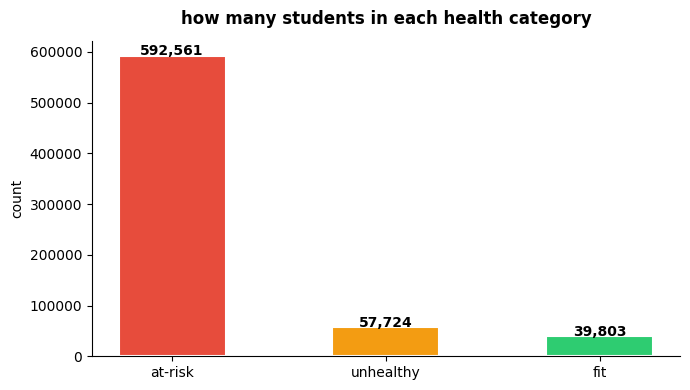

In [329]:
# visualizing class balance
# copying same style from my last project but 
# changing colors and labels

fig, ax = plt.subplots(figsize=(7, 4))

counts = train['health_condition'].value_counts()
colors = ['#E74C3C', '#F39C12', '#2ECC71']

bars = ax.bar(counts.index, counts.values,
              color=colors, width=0.5,
              edgecolor='white', linewidth=1.5)

for bar, val in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 500,
            f'{val:,}',
            ha='center', fontweight='bold')

ax.set_title('how many students in each health category',
             fontweight='bold', pad=12)
ax.set_ylabel('count')
sns.despine()
plt.tight_layout()
plt.show()

In [330]:
# checking missing values
# location column was 33% missing in my last project
# curious what this dataset looks like

missing = train.isnull().sum()
missing_pct = (missing / len(train) * 100).round(2)

print("missing values:")
print(missing_pct[missing_pct > 0])

if missing_pct.sum() == 0:
    print("no missing values - clean dataset!")

missing values:
sleep_duration             11.01
heart_rate                  1.14
bmi                         2.01
calorie_expenditure         7.66
step_count                  2.02
exercise_duration           1.00
water_intake                6.30
diet_type                   1.00
stress_level               12.00
sleep_quality               8.45
physical_activity_level     5.31
smoking_alcohol             4.14
gender                      3.10
dtype: float64


In [331]:
# checking data types
# need to know which columns are numbers 
# and which are categories
# this decides what preprocessing i need to do

print(train.dtypes)
print()
print(f"numeric columns  : {train.select_dtypes(include='number').columns.tolist()}")
print(f"category columns : {train.select_dtypes(include='object').columns.tolist()}")

id                           int64
health_condition            object
sleep_duration             float64
heart_rate                 float64
bmi                        float64
calorie_expenditure        float64
step_count                 float64
exercise_duration          float64
water_intake               float64
diet_type                   object
stress_level                object
sleep_quality               object
physical_activity_level     object
smoking_alcohol             object
gender                      object
dtype: object

numeric columns  : ['id', 'sleep_duration', 'heart_rate', 'bmi', 'calorie_expenditure', 'step_count', 'exercise_duration', 'water_intake']
category columns : ['health_condition', 'diet_type', 'stress_level', 'sleep_quality', 'physical_activity_level', 'smoking_alcohol', 'gender']


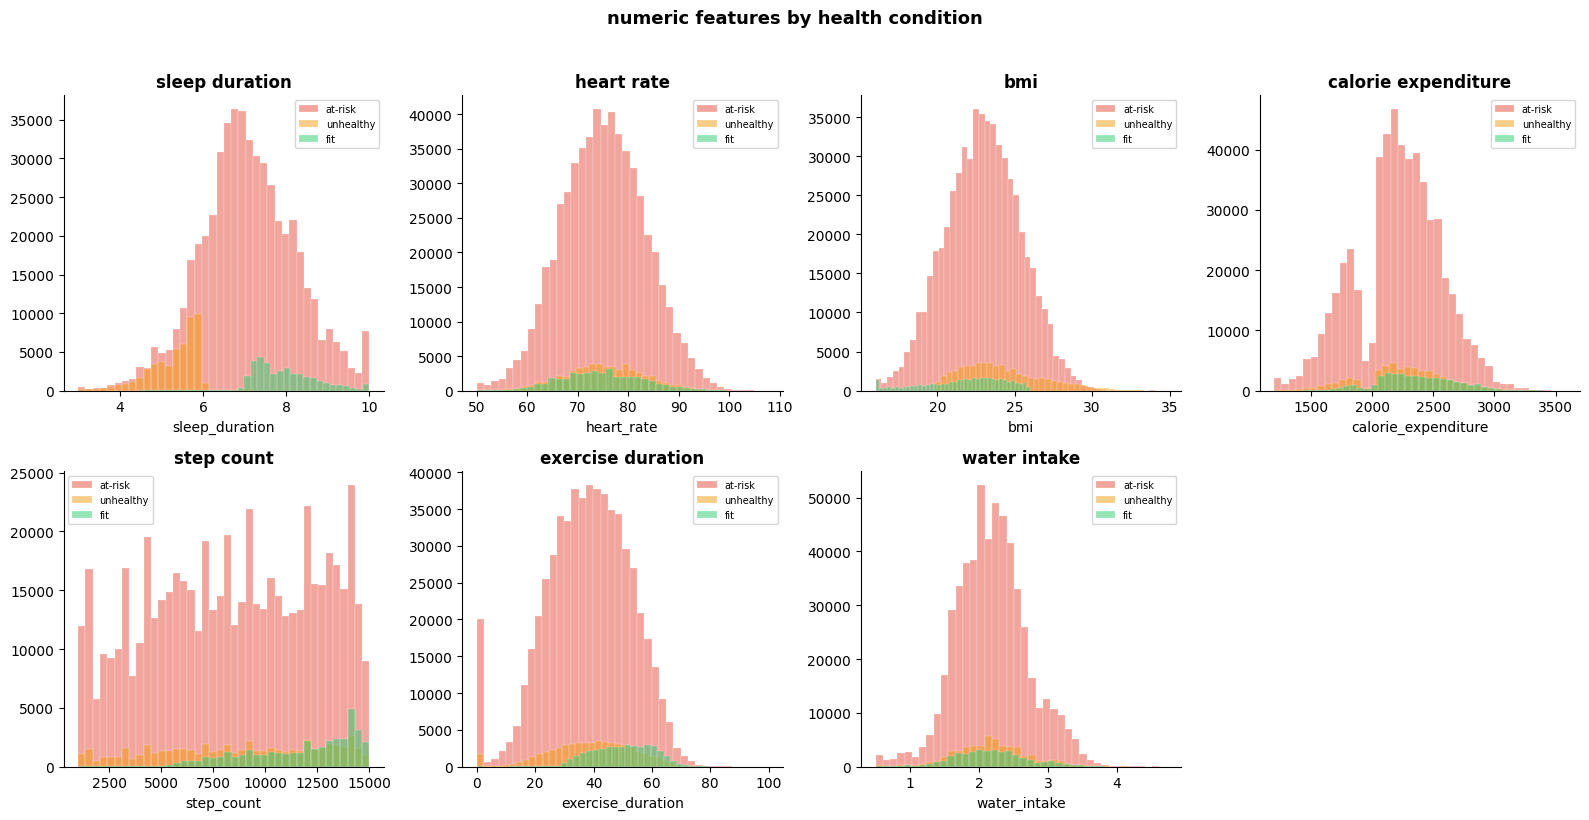

In [332]:
# looking at numeric columns distribution
# want to see if fit students have different 
# bmi or sleep than at-risk students

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

numeric_cols = ['sleep_duration', 'heart_rate', 'bmi', 
                'calorie_expenditure', 'step_count', 
                'exercise_duration', 'water_intake']

colors = {'at-risk': '#E74C3C', 
          'unhealthy': '#F39C12', 
          'fit': '#2ECC71'}

for i, col in enumerate(numeric_cols):
    ax = axes[i]
    for condition, color in colors.items():
        data = train[train['health_condition'] == condition][col].dropna()
        ax.hist(data, bins=40, alpha=0.5,
                color=color, label=condition,
                edgecolor='white', linewidth=0.3)
    ax.set_title(col.replace('_', ' '), fontweight='bold')
    ax.set_xlabel(col)
    ax.legend(fontsize=7)
    sns.despine(ax=ax)

# hiding the last empty subplot
axes[-1].set_visible(False)

plt.suptitle('numeric features by health condition',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

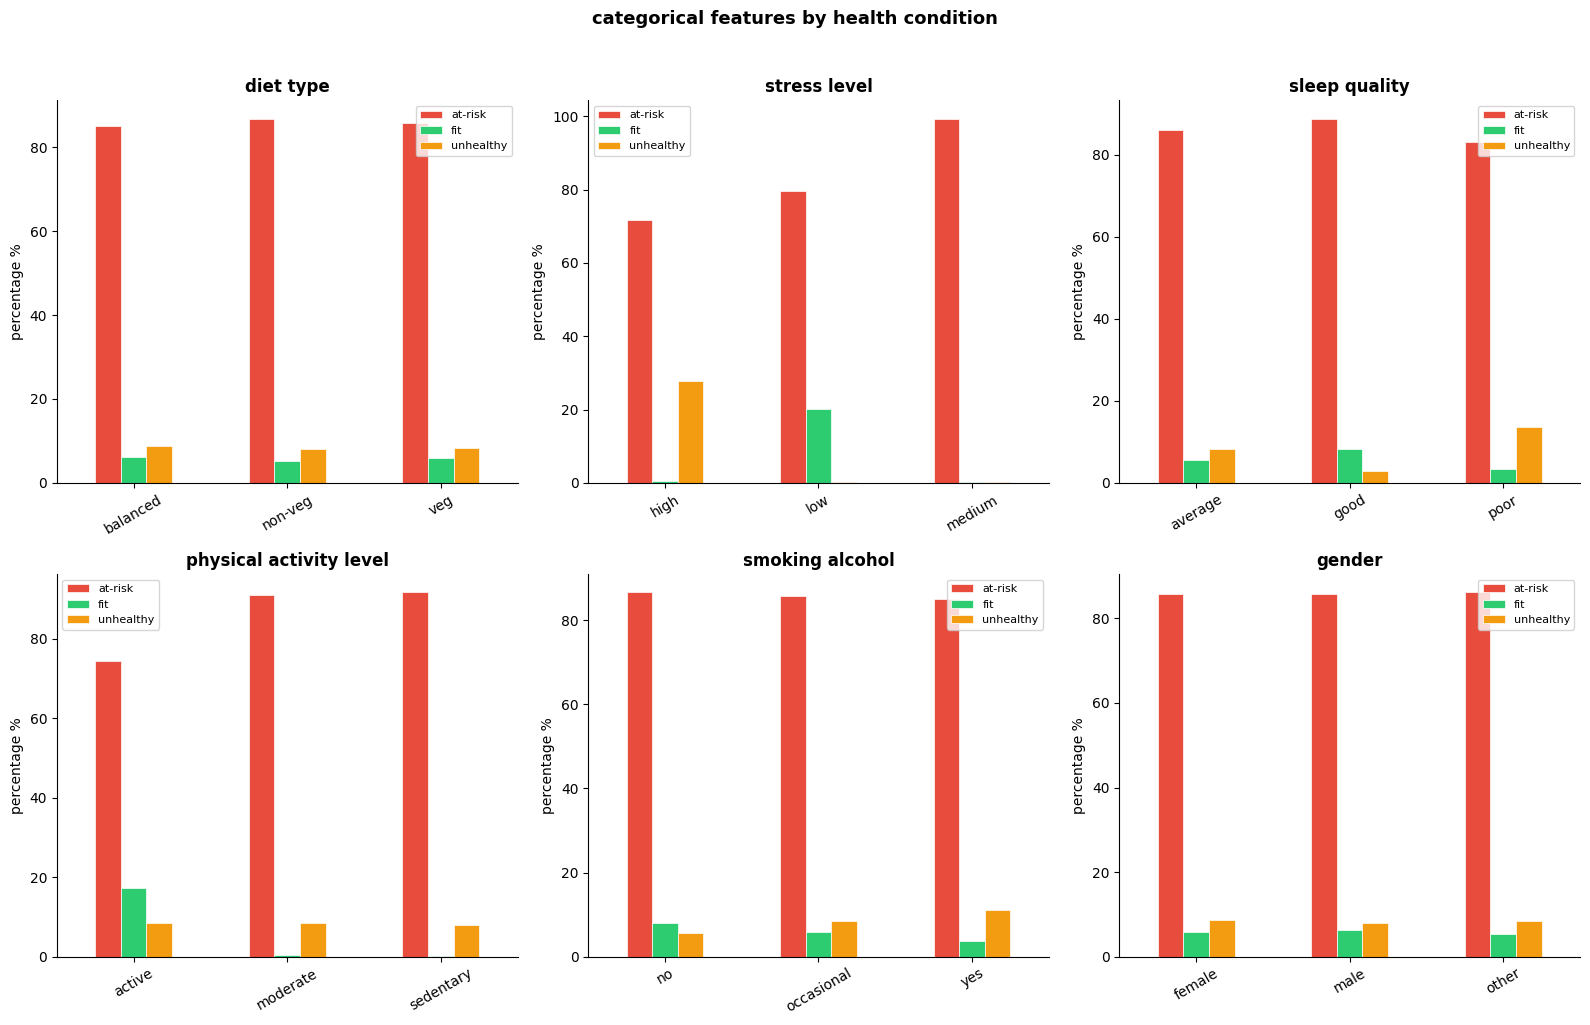

In [333]:
# looking at categorical columns
# want to see if smokers are more at-risk
# or if diet type matters

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

cat_cols = ['diet_type', 'stress_level', 'sleep_quality',
            'physical_activity_level', 'smoking_alcohol', 'gender']

for i, col in enumerate(cat_cols):
    ax = axes[i]
    
    # crosstab shows percentage of each health condition
    # within each category
    ct = pd.crosstab(train[col], 
                     train['health_condition'],
                     normalize='index').mul(100).round(1)
    
    ct.plot(kind='bar', ax=ax, 
            color=['#E74C3C', '#2ECC71', '#F39C12'],
            edgecolor='white', linewidth=0.5)
    
    ax.set_title(col.replace('_', ' '), fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel('percentage %')
    ax.legend(fontsize=8)
    ax.tick_params(axis='x', rotation=30)
    sns.despine(ax=ax)

plt.suptitle('categorical features by health condition',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

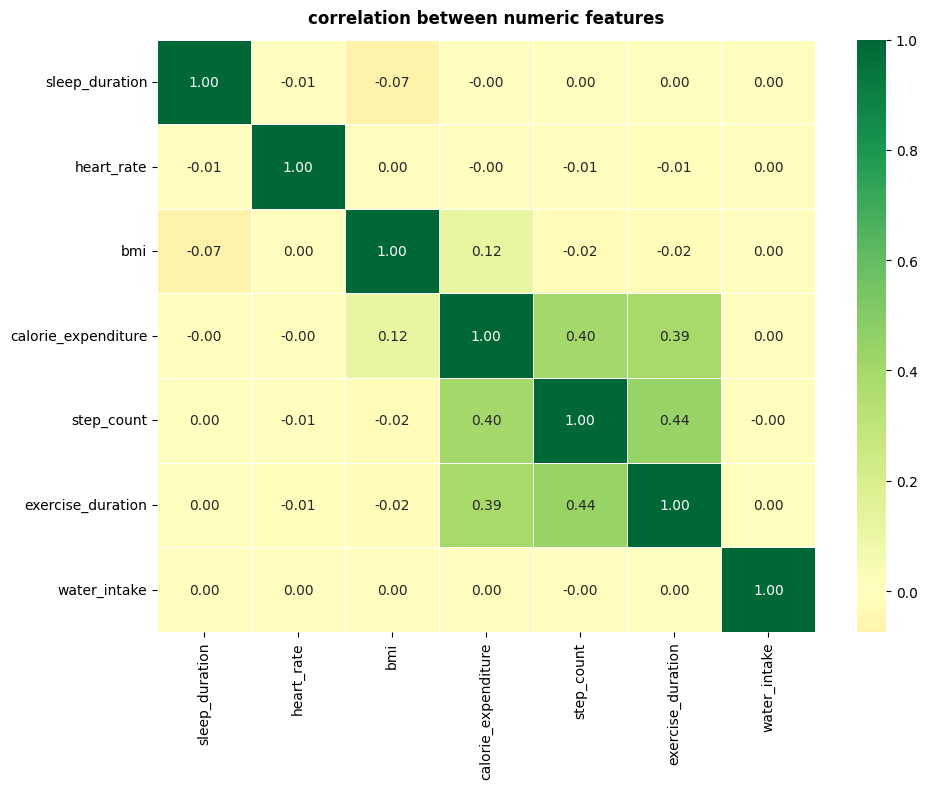

In [334]:
# correlation heatmap for numeric columns
# want to see which features are related to each other
# this is something i did not do in my last project

fig, ax = plt.subplots(figsize=(10, 8))

numeric_data = train[numeric_cols].dropna()
corr = numeric_data.corr()

sns.heatmap(corr, annot=True, fmt='.2f',
            cmap='RdYlGn', center=0,
            linewidths=0.5, linecolor='white',
            ax=ax)

ax.set_title('correlation between numeric features',
             fontweight='bold', pad=12)
plt.tight_layout()
plt.show()

In [335]:
# preprocessing - this is new compared to my last project
# last time i only had text to clean
# this time i have numeric AND categorical columns
# they need completely different treatment

# separating column types first
numeric_cols = ['sleep_duration', 'heart_rate', 'bmi', 
                'calorie_expenditure', 'step_count', 
                'exercise_duration', 'water_intake']

cat_cols = ['diet_type', 'stress_level', 'sleep_quality',
            'physical_activity_level', 'smoking_alcohol', 'gender']

target = 'health_condition'

print("numeric columns:", numeric_cols)
print("categorical columns:", cat_cols)
print("target:", target)

numeric columns: ['sleep_duration', 'heart_rate', 'bmi', 'calorie_expenditure', 'step_count', 'exercise_duration', 'water_intake']
categorical columns: ['diet_type', 'stress_level', 'sleep_quality', 'physical_activity_level', 'smoking_alcohol', 'gender']
target: health_condition


In [336]:
# filling missing values
# learned that you cannot just ignore missing values
# numeric - filling with median because median is 
# not affected by outliers like mean is
# categorical - filling with mode (most common value)

# making copies so original data is safe
train_clean = train.copy()
test_clean  = test.copy()

# filling numeric missing values with median
for col in numeric_cols:
    median_val = train_clean[col].median()
    train_clean[col] = train_clean[col].fillna(median_val)
    test_clean[col]  = test_clean[col].fillna(median_val)
    print(f"{col:<25} filled with median: {median_val:.2f}")

sleep_duration            filled with median: 6.99
heart_rate                filled with median: 75.10
bmi                       filled with median: 22.99
calorie_expenditure       filled with median: 2241.00
step_count                filled with median: 8856.00
exercise_duration         filled with median: 39.40
water_intake              filled with median: 2.17


In [337]:
# filling categorical missing values with mode
# mode means most frequent value

for col in cat_cols:
    mode_val = train_clean[col].mode()[0]
    train_clean[col] = train_clean[col].fillna(mode_val)
    test_clean[col]  = test_clean[col].fillna(mode_val)
    print(f"{col:<25} filled with mode: {mode_val}")

# verifying no missing values remain
print()
print("missing values after filling:")
print(f"train: {train_clean.isnull().sum().sum()}")
print(f"test : {test_clean.isnull().sum().sum()}")

diet_type                 filled with mode: veg
stress_level              filled with mode: medium
sleep_quality             filled with mode: average
physical_activity_level   filled with mode: moderate
smoking_alcohol           filled with mode: yes
gender                    filled with mode: male

missing values after filling:
train: 0
test : 0


In [338]:
# encoding categorical columns
# models only understand numbers not text
# so i need to convert diet_type, stress_level etc
# into numbers
# this is something i did not do in last project
# last project was all text so tfidf handled it
# here i need to do it manually

from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

# encoding target column first
train_clean['health_condition_encoded'] = le.fit_transform(
    train_clean[target])

# saving class names for later
class_names = le.classes_
print("classes found:", class_names)
print("encoded as   :", le.transform(class_names))

classes found: ['at-risk' 'fit' 'unhealthy']
encoded as   : [0 1 2]


In [339]:
# encoding all categorical feature columns
# using a separate encoder for each column

encoders = {}

for col in cat_cols:
    enc = LabelEncoder()
    train_clean[col] = enc.fit_transform(train_clean[col])
    test_clean[col]  = enc.transform(test_clean[col])
    encoders[col]    = enc
    print(f"{col} encoded — classes: {enc.classes_}")

print()
print("all categorical columns encoded successfully")

diet_type encoded — classes: ['balanced' 'non-veg' 'veg']
stress_level encoded — classes: ['high' 'low' 'medium']
sleep_quality encoded — classes: ['average' 'good' 'poor']
physical_activity_level encoded — classes: ['active' 'moderate' 'sedentary']
smoking_alcohol encoded — classes: ['no' 'occasional' 'yes']
gender encoded — classes: ['female' 'male' 'other']

all categorical columns encoded successfully


In [340]:
# preparing final feature matrix
# dropping id and original target column
# keeping everything else as features

features = [col for col in train_clean.columns 
            if col not in ['id', 'health_condition', 
                           'health_condition_encoded']]

X_train = train_clean[features]
y_train = train_clean['health_condition_encoded']
X_test  = test_clean[features]

print(f"X_train shape : {X_train.shape}")
print(f"X_test shape  : {X_test.shape}")
print(f"y_train shape : {y_train.shape}")
print(f"\nfeatures used : {features}")

X_train shape : (690088, 13)
X_test shape  : (295753, 13)
y_train shape : (690088,)

features used : ['sleep_duration', 'heart_rate', 'bmi', 'calorie_expenditure', 'step_count', 'exercise_duration', 'water_intake', 'diet_type', 'stress_level', 'sleep_quality', 'physical_activity_level', 'smoking_alcohol', 'gender']


In [341]:
# model building - starting simple like i learned
# this dataset is huge so random forest will be slow
# starting with logistic regression first
# then trying random forest
# new thing this time - trying xgboost which i never used before

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import balanced_accuracy_score, classification_report
from sklearn.preprocessing import StandardScaler

# splitting data - using smaller validation set
# because dataset is huge
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train, y_train,
    test_size    = 0.2,
    random_state = 42,
    stratify     = y_train  # keeping same class ratio
)

print(f"training samples   : {X_tr.shape[0]:,}")
print(f"validation samples : {X_val.shape[0]:,}")
print()
print("class balance in training:")
for cls, name in zip([0,1,2], ['at-risk','fit','unhealthy']):
    count = (y_tr == cls).sum()
    pct   = count / len(y_tr) * 100
    print(f"  {name:<12} : {count:,} ({pct:.1f}%)")

training samples   : 552,070
validation samples : 138,018

class balance in training:
  at-risk      : 474,049 (85.9%)
  fit          : 31,842 (5.8%)
  unhealthy    : 46,179 (8.4%)


In [342]:
# scaling numeric features
# logistic regression needs this
# tree based models dont need it but doesnt hurt

scaler = StandardScaler()
X_tr_scaled  = scaler.fit_transform(X_tr)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

print("scaling done")
print(f"X_tr_scaled shape  : {X_tr_scaled.shape}")

scaling done
X_tr_scaled shape  : (552070, 13)


In [343]:
# model 1 - logistic regression
# starting simple as always
# this time using balanced class weight
# because 86/8/6 split is very imbalanced

print("training logistic regression...")
print("this might take a minute - dataset is huge")

lr = LogisticRegression(
    class_weight = 'balanced',
    max_iter     = 1000,
    random_state = 42,
    n_jobs       = -1
)

lr.fit(X_tr_scaled, y_tr)
y_pred_lr = lr.predict(X_val_scaled)

# using balanced accuracy this time
# this is the competition metric
# different from f1 score i used before
bal_acc_lr = balanced_accuracy_score(y_val, y_pred_lr)

print()
print("=== logistic regression results ===")
print(f"balanced accuracy : {bal_acc_lr:.4f}")
print()
print(classification_report(y_val, y_pred_lr,
      target_names=['at-risk', 'fit', 'unhealthy']))

training logistic regression...
this might take a minute - dataset is huge

=== logistic regression results ===
balanced accuracy : 0.8165

              precision    recall  f1-score   support

     at-risk       0.98      0.68      0.80    118512
         fit       0.25      0.91      0.39      7961
   unhealthy       0.38      0.86      0.52     11545

    accuracy                           0.71    138018
   macro avg       0.53      0.82      0.57    138018
weighted avg       0.88      0.71      0.76    138018



In [344]:
# model 3 - xgboost
# this is new for me - never used it before
# xgboost is very popular in kaggle competitions
# handles imbalanced data well

from xgboost import XGBClassifier

print("training xgboost...")

xgb = XGBClassifier(
    n_estimators     = 100,
    max_depth        = 6,
    learning_rate    = 0.1,
    random_state     = 42,
    n_jobs           = -1,
    eval_metric      = 'mlogloss',
    use_label_encoder= False
)

xgb.fit(X_tr, y_tr)
y_pred_xgb = xgb.predict(X_val)

bal_acc_xgb = balanced_accuracy_score(y_val, y_pred_xgb)

print()
print("=== xgboost results ===")
print(f"balanced accuracy : {bal_acc_xgb:.4f}")
print()
print(classification_report(y_val, y_pred_xgb,
      target_names=['at-risk', 'fit', 'unhealthy']))

training xgboost...


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [16:11:48] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



=== xgboost results ===
balanced accuracy : 0.8576

              precision    recall  f1-score   support

     at-risk       0.97      1.00      0.98    118512
         fit       0.94      0.80      0.87      7961
   unhealthy       0.97      0.77      0.86     11545

    accuracy                           0.97    138018
   macro avg       0.96      0.86      0.90    138018
weighted avg       0.97      0.97      0.96    138018



model                     balanced accuracy
Logistic Regression                  0.8165
XGBoost                              0.8576

best model: XGBoost (0.8576)


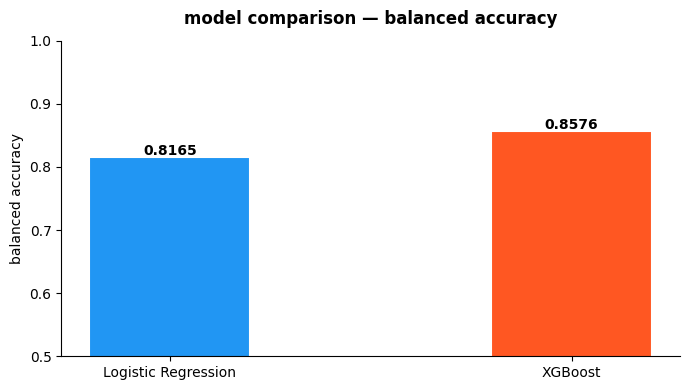

In [351]:
# comparing models that successfully trained
# random forest timed out on 690k rows - too large
# lesson learned - always check dataset size before 
# choosing model

results = {
    'Logistic Regression' : bal_acc_lr,
    'XGBoost'             : bal_acc_xgb
}

print("=" * 45)
print(f"{'model':<22} {'balanced accuracy':>20}")
print("=" * 45)
for model, score in results.items():
    print(f"{model:<22} {score:>20.4f}")
print("=" * 45)

best = max(results, key=results.get)
print(f"\nbest model: {best} ({results[best]:.4f})")

# visual comparison
fig, ax = plt.subplots(figsize=(7, 4))
colors = ['#2196F3', '#FF5722']
bars = ax.bar(results.keys(), results.values(),
              color=colors, width=0.4,
              edgecolor='white', linewidth=1.5)

for bar, val in zip(bars, results.values()):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.002,
            f'{val:.4f}',
            ha='center', fontweight='bold')

ax.set_title('model comparison — balanced accuracy',
             fontweight='bold', pad=12)
ax.set_ylabel('balanced accuracy')
ax.set_ylim(0.5, 1.0)
sns.despine()
plt.tight_layout()
plt.show()

In [348]:
# random forest timed out on this huge dataset
# xgboost won with 0.8576 balanced accuracy
# logistic regression got 0.8165
# using xgboost for submission

# generating predictions on test data
print("generating predictions using xgboost...")
test_preds_encoded = xgb.predict(X_test)

print(f"predictions generated: {len(test_preds_encoded)}")
print(f"unique predictions: {np.unique(test_preds_encoded)}")

generating predictions using xgboost...
predictions generated: 295753
unique predictions: [0 1 2]


In [349]:
# converting encoded predictions back to original labels
# remember the encoding was:
# at-risk = 0, fit = 1, unhealthy = 2
# need to convert numbers back to words for submission

# using the label encoder we saved earlier
test_preds_labels = le.inverse_transform(test_preds_encoded)

print("sample predictions:")
for i in range(5):
    print(f"  student {test['id'].iloc[i]} -> {test_preds_labels[i]}")

print()
print("prediction distribution:")
unique, counts = np.unique(test_preds_labels, return_counts=True)
for label, count in zip(unique, counts):
    print(f"  {label:<12}: {count:,} ({count/len(test_preds_labels)*100:.1f}%)")

sample predictions:
  student 690088 -> unhealthy
  student 690089 -> at-risk
  student 690090 -> at-risk
  student 690091 -> at-risk
  student 690092 -> unhealthy

prediction distribution:
  at-risk     : 262,277 (88.7%)
  fit         : 14,264 (4.8%)
  unhealthy   : 19,212 (6.5%)


In [350]:
# creating submission file
# format must match sample_submission.csv exactly
# two columns - id and health_condition

submission = pd.DataFrame({
    'id'               : test['id'],
    'health_condition' : test_preds_labels
})

submission.to_csv('submission.csv', index=False)

print("submission.csv created successfully")
print(f"shape: {submission.shape}")
print()
print("first 10 rows:")
print(submission.head(10))
print()

# verifying format matches sample submission
print("format check:")
print(f"columns match : {list(submission.columns) == list(sub.columns)}")
print(f"row count match: {len(submission) == len(sub)}")

submission.csv created successfully
shape: (295753, 2)

first 10 rows:
       id health_condition
0  690088        unhealthy
1  690089          at-risk
2  690090          at-risk
3  690091          at-risk
4  690092        unhealthy
5  690093          at-risk
6  690094          at-risk
7  690095          at-risk
8  690096          at-risk
9  690097          at-risk

format check:
columns match : True
row count match: True


In [352]:
# quick summary of what i did in this project
print("=" * 50)
print("  PROJECT SUMMARY")
print("=" * 50)
print()
print("dataset")
print(f"  training rows    : 690,088")
print(f"  test rows        : 295,753")
print(f"  features         : 13")
print(f"  target classes   : 3 (at-risk, fit, unhealthy)")
print(f"  class imbalance  : 86/8/6 — severe")
print()
print("preprocessing")
print(f"  numeric missing  : filled with median")
print(f"  category missing : filled with mode")
print(f"  encoding         : label encoder")
print(f"  scaling          : standard scaler")
print()
print("models")
print(f"  logistic regression : 0.8165")
print(f"  random forest       : timed out - dataset too large")
print(f"  xgboost             : 0.8576 <- best")
print()
print("best model   : XGBoost")
print("metric used  : balanced accuracy")
print("submission   : submission.csv ready")

  PROJECT SUMMARY

dataset
  training rows    : 690,088
  test rows        : 295,753
  features         : 13
  target classes   : 3 (at-risk, fit, unhealthy)
  class imbalance  : 86/8/6 — severe

preprocessing
  numeric missing  : filled with median
  category missing : filled with mode
  encoding         : label encoder
  scaling          : standard scaler

models
  logistic regression : 0.8165
  random forest       : timed out - dataset too large
  xgboost             : 0.8576 <- best

best model   : XGBoost
metric used  : balanced accuracy
submission   : submission.csv ready
